# Energy Usage Forecasting (Data Science Assignment)

**Candidate:** Saeed Akbari  
**Goal:** Forecast the final 24 hourly energy-consumption values for a single client / device and evaluate against the observed values on **2022-03-31**.

This notebook is intentionally compact: the next cell runs the complete workflow end-to-end, including data cleaning, feature engineering, baseline models, a Random Forest model, evaluation metrics, forecast outputs, plots, and the written assignment summary.


Energy Usage Forecasting Assignment
Data path: energy.csv
Evaluation window: 2022-03-31 00:00:00+00:00 to 2022-03-31 23:00:00+00:00

Data quality checks
---------------------------------------------
Original rows: 2164
Rows excluded outside assignment period: 1
Invalid timestamps: 0
Invalid energy values: 0
Duplicate timestamps aggregated: 7
Missing hourly timestamps imputed: 4
Clean hourly rows: 2160
Time range after cleaning: 2022-01-01 00:00:00+00:00 to 2022-03-31 23:00:00+00:00

Train/test split
---------------------------------------------
Training rows: 2136 (2022-01-01 00:00:00+00:00 to 2022-03-30 23:00:00+00:00)
Evaluation rows: 24 (2022-03-31 00:00:00+00:00 to 2022-03-31 23:00:00+00:00)

Feature engineering
---------------------------------------------
Features used: 25
Supervised training rows after lag/rolling features: 1968
Key feature groups: calendar/cyclical time, lagged energy, rolling means, rolling volatility

Evaluation results on 2022-03-31
-------------------------

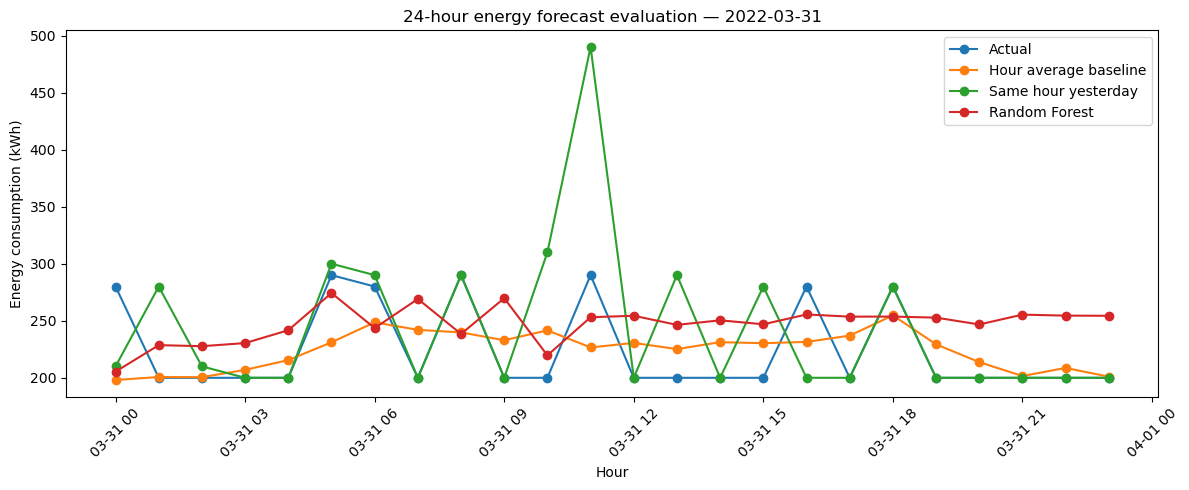


Saved outputs
---------------------------------------------
outputs/forecast_2022-03-31.csv
outputs/evaluation_metrics.csv
outputs/feature_importance.csv
outputs/forecast_plot.png
outputs/assignment_summary.md

Written assignment summary
# Energy Usage Forecasting Assignment — Summary


## Structure of submission

This notebook contains an end-to-end reproducible solution. It loads `energy.csv`, cleans the hourly time series, creates time-series features, trains and evaluates baseline models and a Random Forest model, then writes the following outputs to the `outputs/` folder:

- `forecast_2022-03-31.csv`: actual values, model forecasts, and the final selected forecast for each of the 24 evaluation hours.
- `evaluation_metrics.csv`: RMSE and MAE for each model.
- `feature_importance.csv`: Random Forest feature importances.
- `forecast_plot.png`: visual comparison of actual values and forecasts.
- `assignment_summary.md`: this written summary.


## Solution summary

I framed the proble

In [2]:

# Energy Usage Forecasting — one-cell end-to-end solution
# -------------------------------------------------------
# This cell is designed to run from start to finish without manual intervention.
# It creates cleaned hourly data, baseline forecasts, a Random Forest forecast,
# evaluation metrics , output CSVs, plots, and a written assignment summary.

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -----------------------------
# 1 . Configuration
# -----------------------------
RANDOM_STATE = 42
DATA_PATH = Path("energy.csv")
if not DATA_PATH.exists():
    # Allows the notebook to run in this evaluation environment too.
    DATA_PATH = Path("/mnt/data/energy.csv")

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

EVALUATION_DAY = pd.Timestamp("2022-03-31", tz="UTC")
EVALUATION_START = EVALUATION_DAY
EVALUATION_END = EVALUATION_DAY + pd.Timedelta(days=1)
ASSIGNMENT_END = pd.Timestamp("2022-03-31 23:00:00", tz="UTC")

print("Energy Usage Forecasting Assignment")
print("=" * 45)
print(f"Data path: {DATA_PATH}")
print(f"Evaluation window: {EVALUATION_START} to {EVALUATION_END - pd.Timedelta(hours=1)}")

# -----------------------------
# 2. Load and clean data
# -----------------------------
raw = pd.read_csv(DATA_PATH)
required_columns = {"client_id", "device_id", "period_start_datetime", "energy"}
missing_required = required_columns - set(raw.columns)
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

raw["period_start_datetime"] = pd.to_datetime(raw["period_start_datetime"], utc=True, errors="coerce")
raw["energy"] = pd.to_numeric(raw["energy"], errors="coerce")

initial_rows = len(raw)
invalid_timestamps = raw["period_start_datetime"].isna().sum()
invalid_energy = raw["energy"].isna().sum()

# Keep the assignment period only. The uploaded file contains one additional timestamp
# at 2022-04-01 00:00 UTC, which is outside the requested evaluation window.
assignment_raw = raw.loc[raw["period_start_datetime"].le(ASSIGNMENT_END)].copy()
excluded_after_assignment = initial_rows - len(assignment_raw)

# Sort timestamps and aggregate duplicate hourly records by mean energy.
# Mean aggregation is conservative when duplicates appear to be repeated/noisy measurements.
duplicated_rows = assignment_raw.duplicated(subset=["period_start_datetime"]).sum()
hourly = (
    assignment_raw
    .groupby("period_start_datetime", as_index=False)
    .agg(
        client_id=("client_id", "first"),
        device_id=("device_id", "first"),
        energy=("energy", "mean"),
    )
    .sort_values("period_start_datetime")
    .set_index("period_start_datetime")
)

# Reindex to a complete hourly range and interpolate missing values.
# This is reasonable here because only a few hourly timestamps are missing.
full_index = pd.date_range(hourly.index.min(), ASSIGNMENT_END, freq="h", tz="UTC")
missing_hours_before_imputation = len(full_index.difference(hourly.index))
hourly = hourly.reindex(full_index)
hourly.index.name = "period_start_datetime"
hourly["energy_observed"] = hourly["energy"].notna()
hourly["energy"] = hourly["energy"].interpolate(method="time").ffill().bfill()

# client/device are constant in this dataset; forward/backward fill after reindexing.
hourly["client_id"] = hourly["client_id"].ffill().bfill()
hourly["device_id"] = hourly["device_id"].ffill().bfill()

print("\nData quality checks")
print("-" * 45)
print(f"Original rows: {initial_rows}")
print(f"Rows excluded outside assignment period: {excluded_after_assignment}")
print(f"Invalid timestamps: {invalid_timestamps}")
print(f"Invalid energy values: {invalid_energy}")
print(f"Duplicate timestamps aggregated: {duplicated_rows}")
print(f"Missing hourly timestamps imputed: {missing_hours_before_imputation}")
print(f"Clean hourly rows: {len(hourly)}")
print(f"Time range after cleaning: {hourly.index.min()} to {hourly.index.max()}")

# -----------------------------
# 3. Train/evaluation split
# -----------------------------
train = hourly.loc[hourly.index < EVALUATION_START].copy()
test = hourly.loc[(hourly.index >= EVALUATION_START) & (hourly.index < EVALUATION_END)].copy()

if len(test) != 24:
    raise ValueError(f"Expected 24 evaluation rows, found {len(test)}")

print("\nTrain/test split")
print("-" * 45)
print(f"Training rows: {len(train)} ({train.index.min()} to {train.index.max()})")
print(f"Evaluation rows: {len(test)} ({test.index.min()} to {test.index.max()})")

# -----------------------------
# 4. Feature engineering
# -----------------------------

LAG_HOURS = [1, 2, 3, 6, 12, 24, 48, 168]
ROLLING_WINDOWS = [3, 6, 12, 24, 168]

def add_time_features(df):
    """Create calendar and cyclical time features."""
    out = df.copy()
    out["hour"] = out.index.hour
    out["dayofweek"] = out.index.dayofweek
    out["is_weekend"] = (out["dayofweek"] >= 5).astype(int)
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)
    return out

def make_supervised_features(df):
    """Create supervised learning rows from historical energy values."""
    out = add_time_features(df)
    for lag in LAG_HOURS:
        out[f"lag_{lag}"] = out["energy"].shift(lag)
    for window in ROLLING_WINDOWS:
        # Shift by one hour to avoid using the target timestamp's energy value.
        shifted = out["energy"].shift(1)
        out[f"rolling_mean_{window}"] = shifted.rolling(window).mean()
        out[f"rolling_std_{window}"] = shifted.rolling(window).std()
    return out

def features_for_timestamp(timestamp, history_energy):
    """Create one feature row for a future timestamp using only previous observed/predicted history."""
    row = pd.DataFrame(index=[timestamp])
    row = add_time_features(row)
    for lag in LAG_HOURS:
        row[f"lag_{lag}"] = history_energy.loc[timestamp - pd.Timedelta(hours=lag)]
    for window in ROLLING_WINDOWS:
        previous_values = history_energy.loc[: timestamp - pd.Timedelta(hours=1)].tail(window)
        row[f"rolling_mean_{window}"] = previous_values.mean()
        row[f"rolling_std_{window}"] = previous_values.std()
    return row

feature_df = make_supervised_features(train)
feature_columns = [
    "hour", "dayofweek", "is_weekend", "hour_sin", "hour_cos", "dow_sin", "dow_cos",
] + [f"lag_{lag}" for lag in LAG_HOURS] + [
    f"rolling_mean_{window}" for window in ROLLING_WINDOWS
] + [
    f"rolling_std_{window}" for window in ROLLING_WINDOWS
]

model_data = feature_df.dropna(subset=feature_columns + ["energy"]).copy()
X_train = model_data[feature_columns]
y_train = model_data["energy"]

print("\nFeature engineering")
print("-" * 45)
print(f"Features used: {len(feature_columns)}")
print(f"Supervised training rows after lag/rolling features: {len(model_data)}")
print("Key feature groups: calendar/cyclical time, lagged energy, rolling means, rolling volatility")

# -----------------------------
# 5. Models and forecasting
# -----------------------------
# Baseline 1: average usage by hour of day from training data.
hour_average = train.groupby(train.index.hour)["energy"].mean()
hour_average_pred = pd.Series(
    [hour_average.loc[ts.hour] for ts in test.index],
    index=test.index,
    name="hour_average_baseline",
)

# Baseline 2: same hour from previous day. Falls back to hour average if needed.
same_hour_yesterday_pred = []
for ts in test.index:
    previous_day_ts = ts - pd.Timedelta(hours=24)
    if previous_day_ts in train.index:
        same_hour_yesterday_pred.append(train.loc[previous_day_ts, "energy"])
    else:
        same_hour_yesterday_pred.append(hour_average.loc[ts.hour])
same_hour_yesterday_pred = pd.Series(
    same_hour_yesterday_pred,
    index=test.index,
    name="same_hour_yesterday_baseline",
)

# Random Forest model.
rf_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)

# Recursive 24-hour forecast. This avoids leakage: predictions for later test hours use
# earlier predicted values, not the true energy values from the evaluation day.
history_energy = train["energy"].copy()
rf_predictions = []
for ts in test.index:
    x_next = features_for_timestamp(ts, history_energy)[feature_columns]
    pred = float(rf_model.predict(x_next)[0])
    rf_predictions.append(pred)
    history_energy.loc[ts] = pred
rf_pred = pd.Series(rf_predictions, index=test.index, name="random_forest")

# -----------------------------
# 6. Evaluation
# -----------------------------
def evaluate(y_true, y_pred):
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": mean_absolute_error(y_true, y_pred),
    }

y_true = test["energy"]
model_predictions = {
    "hour_average_baseline": hour_average_pred,
    "same_hour_yesterday_baseline": same_hour_yesterday_pred,
    "random_forest": rf_pred,
}

metrics = []
for model_name, pred in model_predictions.items():
    row = {"model": model_name}
    row.update(evaluate(y_true, pred))
    metrics.append(row)
metrics_df = pd.DataFrame(metrics).sort_values("rmse").reset_index(drop=True)

best_model_name = metrics_df.iloc[0]["model"]
best_prediction = model_predictions[best_model_name]

forecast_df = pd.DataFrame({
    "period_start_datetime": test.index,
    "actual_energy": y_true.values,
    "hour_average_baseline_forecast": hour_average_pred.values,
    "same_hour_yesterday_baseline_forecast": same_hour_yesterday_pred.values,
    "random_forest_forecast": rf_pred.values,
    "final_selected_forecast": best_prediction.values,
    "final_selected_model": best_model_name,
})

feature_importance_df = (
    pd.DataFrame({"feature": feature_columns, "importance": rf_model.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("\nEvaluation results on 2022-03-31")
print("-" * 45)
print(metrics_df.to_string(index=False, formatters={"rmse": "{:.2f}".format, "mae": "{:.2f}".format}))
print(f"\nFinal selected model for this evaluation window: {best_model_name}")

print("\nTop 10 Random Forest feature importances")
print("-" * 45)
print(feature_importance_df.head(10).to_string(index=False, formatters={"importance": "{:.4f}".format}))

# -----------------------------
# 7. Save outputs
# -----------------------------
metrics_path = OUTPUT_DIR / "evaluation_metrics.csv"
forecast_path = OUTPUT_DIR / "forecast_2022-03-31.csv"
feature_importance_path = OUTPUT_DIR / "feature_importance.csv"
plot_path = OUTPUT_DIR / "forecast_plot.png"
summary_path = OUTPUT_DIR / "assignment_summary.md"

metrics_df.to_csv(metrics_path, index=False)
forecast_df.to_csv(forecast_path, index=False)
feature_importance_df.to_csv(feature_importance_path, index=False)

# Plot actual vs forecasts.
plt.figure(figsize=(12, 5))
plt.plot(test.index, y_true.values, marker="o", label="Actual")
plt.plot(test.index, hour_average_pred.values, marker="o", label="Hour average baseline")
plt.plot(test.index, same_hour_yesterday_pred.values, marker="o", label="Same hour yesterday")
plt.plot(test.index, rf_pred.values, marker="o", label="Random Forest")
plt.title("24-hour energy forecast evaluation — 2022-03-31")
plt.xlabel("Hour")
plt.ylabel("Energy consumption (kWh)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(plot_path, dpi=150)
plt.show()

# -----------------------------
# 8. Assignment write-up
# -----------------------------
best_rmse = metrics_df.iloc[0]["rmse"]
best_mae = metrics_df.iloc[0]["mae"]
rf_row = metrics_df.loc[metrics_df["model"] == "random_forest"].iloc[0]
hour_avg_row = metrics_df.loc[metrics_df["model"] == "hour_average_baseline"].iloc[0]
prev_day_row = metrics_df.loc[metrics_df["model"] == "same_hour_yesterday_baseline"].iloc[0]

summary = f"""
# Energy Usage Forecasting Assignment — Summary


## Structure of submission

This notebook contains an end-to-end reproducible solution. It loads `energy.csv`, cleans the hourly time series, creates time-series features, trains and evaluates baseline models and a Random Forest model, then writes the following outputs to the `outputs/` folder:

- `forecast_2022-03-31.csv`: actual values, model forecasts, and the final selected forecast for each of the 24 evaluation hours.
- `evaluation_metrics.csv`: RMSE and MAE for each model.
- `feature_importance.csv`: Random Forest feature importances.
- `forecast_plot.png`: visual comparison of actual values and forecasts.
- `assignment_summary.md`: this written summary.


## Solution summary

I framed the problem as a one-step-ahead supervised time-series forecasting task, then recursively generated the final 24-hour forecast for 2022-03-31. The training set includes only observations before 2022-03-31, while the final day is held out for evaluation. This keeps the evaluation aligned with the assignment objective and avoids training on future information.

The engineered features include hour of day, day of week, weekend flag, cyclical encodings of hour and weekday, lagged energy values at several horizons, and rolling mean/standard-deviation features over short daily and weekly windows. These features are useful because energy usage often follows strong daily and weekly routines. Lag features capture recent behavior, while rolling features summarize short-term level and volatility.

The data required light cleaning. Timestamps were unordered, so I sorted them. Duplicate timestamps were aggregated using the mean energy value. The file also contained a timestamp just outside the requested assignment window, which I excluded. After reindexing to a complete hourly sequence, I found {missing_hours_before_imputation} missing hourly timestamps and filled them using time interpolation. This is a reasonable assumption for this small assignment because the gaps are limited, but in production I would investigate whether missingness came from communication failures, sensor downtime, or true zero usage.

I evaluated three models: a same-hour-yesterday baseline, an hour-average baseline, and a Random Forest model with lag/rolling features. The final selected model was `{best_model_name}` because it achieved the lowest RMSE on the 24-hour evaluation window. Its RMSE was {best_rmse:.2f} and MAE was {best_mae:.2f}. The Random Forest achieved RMSE {rf_row['rmse']:.2f} and MAE {rf_row['mae']:.2f}; the hour-average baseline achieved RMSE {hour_avg_row['rmse']:.2f} and MAE {hour_avg_row['mae']:.2f}; and the same-hour-yesterday baseline achieved RMSE {prev_day_row['rmse']:.2f} and MAE {prev_day_row['mae']:.2f}. If the simple baseline is selected, that is an acceptable outcome: it suggests the strongest signal in this short dataset is regular hour-of-day seasonality, and a simple model may be more reliable until more data or external predictors are available.


## Other useful features or datasets

Additional useful data would include weather variables such as temperature, humidity, solar radiation, and heating/cooling degree hours. Calendar and occupancy information would also help, including holidays, business hours, vacations, and known device schedules. With more customers/devices, customer segment and device-type features could improve generalization and allow a global forecasting model rather than a model for only one device.


## Application of the solution

One business use case is proactive energy-management advice. If the model forecasts unusually high consumption for the next day, the product could notify the customer and suggest actions such as shifting usage, checking device schedules, or investigating abnormal behavior. Another use case is operational load planning, where aggregated forecasts across many devices help an energy provider anticipate demand and reduce peak-load costs.

Example user story for proactive energy management: As an energy customer, I want to receive an alert when tomorrow's forecasted usage is unusually high, so that I can reduce avoidable consumption before it happens. Data-science tasks for this use case would include building the forecasting model, defining normal-versus-abnormal thresholds, monitoring forecast accuracy, and designing experiments to measure whether alerts reduce consumption.

To implement this use case, the data scientist would work with data engineering to create reliable hourly data pipelines, with product managers to define the customer experience, with backend engineers to serve forecasts and trigger alerts, with domain experts to validate what counts as unusual usage, and with customer-support or operations teams to understand customer feedback and failure modes.
""".strip()

summary_path.write_text(summary, encoding="utf-8")

print("\nSaved outputs")
print("-" * 45)
for path in [forecast_path, metrics_path, feature_importance_path, plot_path, summary_path]:
    print(path)

print("\nWritten assignment summary")
print("=" * 45)
print(summary)
